In [13]:
from astropy.table import Table, vstack, hstack
from astroquery.jplsbdb import SBDB
from tqdm import tqdm
import numpy as np
import astropy.units as u

# -----------------------------
# 1. 读取原始数据
# -----------------------------
t = Table.read("matched_asteroids.fits")

# -----------------------------
# 2. 构造查询 ID：优先用编号，否则用名字
# -----------------------------
query_ids = []
for num, name in zip(t['number'], t['name']):
    if (num is not np.ma.masked) and (num is not None):
        query_ids.append(str(int(num)))
    else:
        query_ids.append(str(name).strip())

# -----------------------------
# 3. 扁平化 SBDB 返回的结果
# -----------------------------
def flatten_sbdb(res):
    """
    将 SBDB.query 返回的嵌套字典扁平化为一行 Table。
    Quantity 转 float，列表/字典/None 转字符串，保证 vstack 不报错。
    """
    flat_dict = {}

    def _flatten(prefix, obj):
        if isinstance(obj, dict):
            for k, v in obj.items():
                _flatten(f"{prefix}_{k}" if prefix else k, v)
        elif isinstance(obj, u.Quantity):
            flat_dict[prefix] = float(obj.value)  # 保留数值
        elif isinstance(obj, list):
            flat_dict[prefix] = str(obj)
        elif obj is None:
            flat_dict[prefix] = ""  # None 转空字符串
        else:
            flat_dict[prefix] = str(obj)  # 其他类型统一转字符串

    _flatten("", res)
    return Table([flat_dict])

# -----------------------------
# 4. 循环查询 SBDB 并扁平化
# -----------------------------
sbdb_rows = []

for obj_id in tqdm(query_ids, desc="Querying SBDB", unit="obj"):
    try:
        res = SBDB.query(obj_id)
        row = flatten_sbdb(res)
        sbdb_rows.append(row)
    except Exception as e:
        tqdm.write(f"查询 {obj_id} 失败: {e}")
        # 插入空行保持长度一致
        if sbdb_rows:
            sbdb_rows.append(Table({col: [None] for col in sbdb_rows[0].colnames}))
        else:
            sbdb_rows.append(Table({'query_failed': [True]}))

# -----------------------------
# 5. 合并所有 SBDB 行
# -----------------------------
sbdb_all = vstack(sbdb_rows, metadata_conflicts='silent')

# -----------------------------
# 6. 横向合并原始表
# -----------------------------
final_table = hstack([t, sbdb_all], join_type='exact')

# -----------------------------
# 7. 保存为 FITS
# -----------------------------
final_table.write('matched_asteroids_sbdb.fits', overwrite=True)
print("保存完成：matched_asteroids_sbdb.fits")


Querying SBDB:  19%|█▉        | 13134/69380 [1:01:50<79:39:32,  5.10s/obj]

查询 18504 失败: HTTPSConnectionPool(host='ssd-api.jpl.nasa.gov', port=443): Max retries exceeded with url: /sbdb.api?sstr=18504 (Caused by ProxyError('Unable to connect to proxy', RemoteDisconnected('Remote end closed connection without response')))


Querying SBDB:  19%|█▉        | 13135/69380 [1:02:10<151:52:58,  9.72s/obj]

查询 18584 失败: HTTPSConnectionPool(host='ssd-api.jpl.nasa.gov', port=443): Max retries exceeded with url: /sbdb.api?sstr=18584 (Caused by SSLError(SSLZeroReturnError(6, 'TLS/SSL connection has been closed (EOF) (_ssl.c:1147)')))


Querying SBDB:  24%|██▍       | 16704/69380 [1:17:18<4:03:45,  3.60obj/s]  


KeyboardInterrupt: 

In [1]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

"""
批量将 MPCORB 轨道信息匹配到小行星表
------------------------------------------------
输入：
    matched_asteroids.fits   —— 原始小行星表（含 number, name）
    MPCORB_20250706.DAT      —— 最新 MPCORB 数据文件
输出：
    matched_asteroids_mpcorb_fuzzy.fits —— 匹配后结果表
"""

from astropy.table import Table, hstack
import numpy as np
import re
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm

# -----------------------------
# 0. 路径配置
# -----------------------------
INPUT_FITS = "./asteroid_result/matched_asteroids.fits"
MPCORB_FILE = "MPCORB_20250706.DAT"
OUTPUT_FITS = "matched_asteroids_mpcorb.fits"


# -----------------------------
# 1. 安全 float 转换函数
# -----------------------------
def safe_float(x):
    try:
        return float(x)
    except Exception:
        return np.nan


# -----------------------------
# 2. 解析新版 MPCORB 行（名字在末尾）
# -----------------------------
def parse_mpcorb_line(line):
    """
    解析新版 MPCORB.dat (名字在行尾 "(xxx) Name yyyyMMdd")。
    返回字典。
    """
    ln = line.rstrip("\n")
    if ln.strip() == "" or ln.startswith("#"):
        return None

    # 匹配末尾的 "(number) Name YYYYMMDD"
    name_match = re.search(r"\((\d+)\)\s*([A-Za-z0-9\-\s]+?)\s*\d{8}$", ln)
    if name_match:
        number = name_match.group(1).strip()
        name = name_match.group(2).strip()
        # 删除尾部名字部分
        line_core = ln[:name_match.start()].strip()
    else:
        # 没匹配到名字也要保留
        number = ln[0:7].strip()
        name = ""
        line_core = ln

    parts = line_core.split()
    if len(parts) < 11:
        return None

    out = {}
    out["mpc_number"] = number
    out["mpc_name"] = name
    out["H"] = safe_float(parts[1])
    out["G"] = safe_float(parts[2])
    out["epoch"] = parts[3]
    out["M"] = safe_float(parts[4])
    out["w"] = safe_float(parts[5])
    out["Omega"] = safe_float(parts[6])
    out["i"] = safe_float(parts[7])
    out["e"] = safe_float(parts[8])
    out["n"] = safe_float(parts[9])
    out["a"] = safe_float(parts[10])
    out["extra_tokens"] = " ".join(parts[11:])
    return out


# -----------------------------
# 3. 读取 MPCORB
# -----------------------------
def load_mpcorb(filename):
    """
    读取 MPCORB 文件，跳过头部说明，解析每行轨道元素。
    """
    rows = []
    with open(filename, "r", encoding="utf-8", errors="ignore") as f:
        for line in tqdm(f, desc="读取 MPCORB", unit="行"):
            row = parse_mpcorb_line(line)
            if row is not None and str(row["mpc_number"]).isdigit():
                rows.append(row)
    t = Table(rows)
    return t


# -----------------------------
# 4. 匹配单个小行星
# -----------------------------
def match_single(row, mpc_by_number, mpc_by_name):
    """匹配单个小行星：优先 number，其次 name"""
    num = row["number"]
    name = str(row["name"]).strip()

    # 优先按编号匹配
    if num not in (None, "", np.ma.masked):
        key = str(int(num))
        if key in mpc_by_number:
            return mpc_by_number[key]

    # 否则按名字匹配（大小写无关）
    key = name.lower()
    if key in mpc_by_name:
        return mpc_by_name[key]

    # 没找到则返回空行
    return {col: np.nan for col in mpc_by_number[next(iter(mpc_by_number))].keys()}


# -----------------------------
# 5. 自动修正列类型
# -----------------------------
def fix_column_types(table):
    """
    自动修正 Astropy Table 中的列类型，避免 FITS 写入报错
    """
    for colname in table.colnames:
        col = table[colname]
        vals = np.array(col)

        if len(vals) == 0:
            continue

        if vals.dtype.kind in ("f", "i"):
            continue
        elif vals.dtype.kind in ("O", "U"):
            # 尝试 float
            newcol = []
            for v in vals:
                try:
                    newcol.append(float(v))
                except:
                    newcol.append(str(v) if v is not None else "")
            table.replace_column(colname, newcol)
    return table


# -----------------------------
# 6. 主程序
# -----------------------------
if __name__ == "__main__":
    print("读取输入 FITS:", INPUT_FITS)
    t = Table.read(INPUT_FITS)
    print(f"原始表包含 {len(t)} 行")

    print("读取 MPCORB 文件...")
    mpc = load_mpcorb(MPCORB_FILE)
    print(f"读取 {len(mpc)} 条 MPC 记录")

    # 建立索引字典以加快匹配
    mpc_by_number = {str(int(num)): dict(row) for num, row in zip(mpc["mpc_number"], mpc)}
    mpc_by_name = {str(name).strip().lower(): dict(row) for name, row in zip(mpc["mpc_name"], mpc)}

    print("开始匹配...")
    results = []
    with ThreadPoolExecutor(max_workers=8) as executor:
        for res in tqdm(executor.map(lambda r: match_single(r, mpc_by_number, mpc_by_name), t),
                        total=len(t), desc="匹配小行星", unit="obj"):
            results.append(res)

    # 转换匹配结果为 Table
    mpc_matched = Table(rows=results)

    # 修正列类型
    mpc_matched = fix_column_types(mpc_matched)

    print("横向合并结果表...")
    final_table = hstack([t, mpc_matched], join_type="exact")

    print("写入输出 FITS:", OUTPUT_FITS)
    final_table.write(OUTPUT_FITS, overwrite=True)
    print("✅ 完成。输出文件:", OUTPUT_FITS)


读取输入 FITS: ./asteroid_result/matched_asteroids.fits
原始表包含 79440 行
读取 MPCORB 文件...


读取 MPCORB: 1455506行 [00:03, 376717.47行/s]


读取 811538 条 MPC 记录
开始匹配...


匹配小行星: 100%|██████████| 79440/79440 [00:00<00:00, 1217437.17obj/s]


横向合并结果表...
写入输出 FITS: matched_asteroids_mpcorb.fits
✅ 完成。输出文件: matched_asteroids_mpcorb.fits


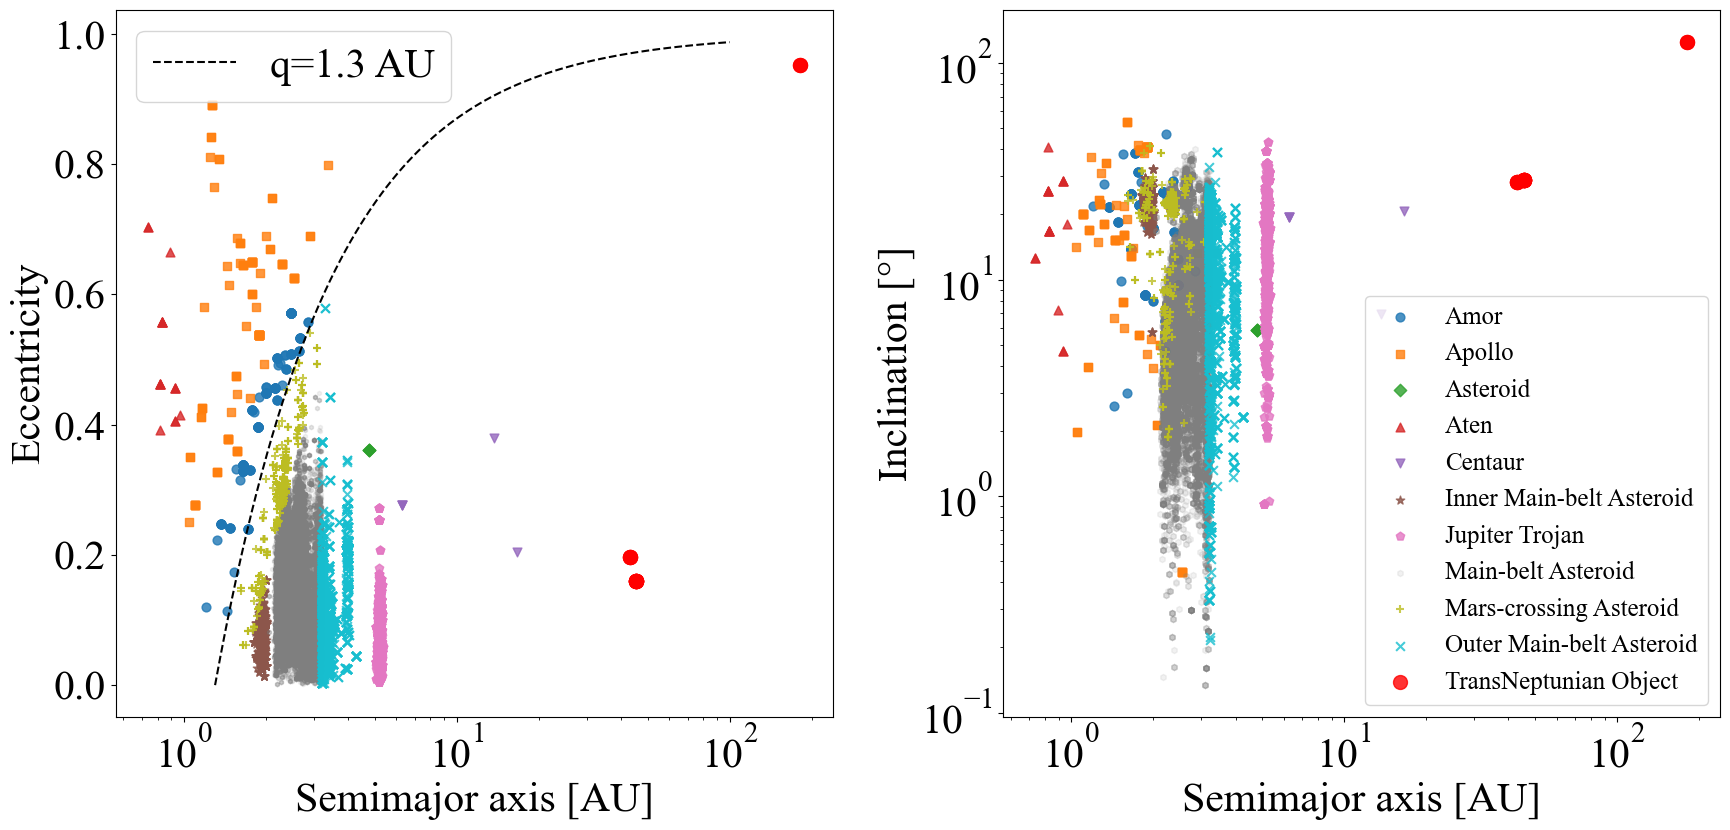

In [1]:
import matplotlib.pyplot as plt
from astropy.table import Table
import numpy as np

def str_to_float(arr, unit=None):
    """
    将 SBDB 保存的字符串数组转换为 float。
    如果字符串中有单位（如 'AU', 'deg'），去掉单位再转 float。
    无效数值（空字符串、'--'）自动转 np.nan
    """
    out = []
    for x in arr:
        if x is None:
            out.append(np.nan)
            continue
        s = str(x).strip()
        if s in ('', '--', 'nan', 'NaN'):
            out.append(np.nan)
            continue
        if unit and s.endswith(unit):
            s = s[:-len(unit)].strip()
        try:
            out.append(float(s))
        except ValueError:
            out.append(np.nan)
    return np.array(out, dtype=float)

# -----------------------------
# 1. 读取 FITS
# -----------------------------
t = Table.read("/Users/yunaoxiao/Desktop/sitian.fits")

# -----------------------------
# 2. 提取并转换数据
# -----------------------------
a = str_to_float(t['orbit_elements_a'], unit='AU')
e = str_to_float(t['orbit_elements_e'])        # 离心率本身无单位
i = str_to_float(t['orbit_elements_i'], unit='deg')
classes = np.array(t['object_orbit_class_name'], dtype=str)

# -----------------------------
# 3. 分类准备
# -----------------------------
unique_classes = np.unique(classes)
markers = ['o', 's', 'D', '^', 'v', '*', 'p', 'h', '+', 'x']
colors = plt.cm.tab10.colors  # 默认10色循环

class_marker_color = {}
for idx, cls in enumerate(unique_classes):
    class_marker_color[cls] = (markers[idx % len(markers)],
                               colors[idx % len(colors)])

# -----------------------------
# 4. 创建画布和子图
# -----------------------------
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 30

fig, axes = plt.subplots(1, 2, figsize=(18, 9))
ax1, ax2 = axes

# -----------------------------
# 5. 绘制 a vs e（左图）
# -----------------------------
for cls in unique_classes:
    mask = classes == cls
    if cls == 'TransNeptunian Object':
        alpha_val = 0.8
        color_val = 'r'
        size_val = 100
    elif cls == 'Main-belt Asteroid':
        alpha_val = 0.1
        color_val = class_marker_color[cls][1]
        size_val = 10
    else:
        alpha_val = 0.8
        color_val = class_marker_color[cls][1]
        size_val = 40

    ax1.scatter(a[mask], e[mask],
                marker=class_marker_color[cls][0],
                color=color_val,
                s=size_val,
                alpha=alpha_val)

# q = 1.3 AU 虚线
a_line = np.logspace(np.log10(1.3), 2, 100)
e_line = 1 - 1.3 / a_line
ax1.plot(a_line, e_line, 'k--', label='q=1.3 AU')
ax1.legend()
ax1.set_xscale('log')
ax1.set_xlabel('Semimajor axis [AU]')
ax1.set_ylabel('Eccentricity')

# -----------------------------
# 6. 绘制 a vs i（右图）
# -----------------------------
for cls in unique_classes:
    mask = classes == cls
    if cls == 'TransNeptunian Object':
        alpha_val = 0.8
        color_val = 'r'
        size_val = 100
    elif cls == 'Main-belt Asteroid':
        alpha_val = 0.1
        color_val = class_marker_color[cls][1]
        size_val = 20
    else:
        alpha_val = 0.8
        color_val = class_marker_color[cls][1]
        size_val = 40

    ax2.scatter(a[mask], i[mask],
                marker=class_marker_color[cls][0],
                color=color_val,
                s=size_val,
                alpha=alpha_val,
                label=cls)

ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel('Semimajor axis [AU]')
ax2.set_ylabel('Inclination [°]')
ax2.legend(fontsize=18, loc='best')

plt.tight_layout()
plt.savefig('/Users/yunaoxiao/Desktop/asteroid_orbits.png', dpi=300)
plt.show()
